In [326]:
import pandas as pd
import numpy as np

In [327]:
df = pd.read_csv("HR-Employee-Attrition.csv")

In [328]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [329]:
df.shape   # rows,columns

(1470, 35)

In [330]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [331]:
attrition_counts = df["Attrition"].value_counts()
attrition_percentage =df["Attrition"].value_counts(normalize= True)*100

# normalize will return the proportions instead of raw counts

print(attrition_counts)
print(f"\n{attrition_percentage.round(2).astype(str) + "%"}")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.88%
Yes    16.12%
Name: proportion, dtype: object


In [332]:
# clearly 237(16.12%) people left company and 1233 stayed(83.88)

In [333]:
num_col = df.select_dtypes(include = np.number).columns.tolist() 
cat_col = df.select_dtypes(exclude = np.number).columns.tolist()
print("Numerical columns:  ", num_col)
print("\n Categorical columns : ", cat_col)

Numerical columns:   ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

 Categorical columns :  ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [334]:
attrition_rate = (df["Attrition"].eq("Yes").mean())* 100
print(f"\nAttrition rate: {attrition_rate:.2f}%")

if attrition_rate < 40:
    print("Observation: Dataset is imbalanced because fewer employees left than stayed")
else:
    print("Observation: Dataset looks  balanced")
    


Attrition rate: 16.12%
Observation: Dataset is imbalanced because fewer employees left than stayed


In [335]:
#TASK 2  Data cleaning and preprocessing

In [336]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [337]:
df.isnull().sum()  #missing value check

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [338]:
df.duplicated().sum   #check for duplicates

<bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
1465    False
1466    False
1467    False
1468    False
1469    False
Length: 1470, dtype: bool>

In [339]:
df_clean = df.copy()  # orginal dataset remains unchanged

In [340]:
col_drop = ["EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]
df_clean = df_clean.drop( col_drop,  axis = 1)  # we will drop unneccesary columns
df_clean.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [341]:
df_clean.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [342]:

if df_clean["Attrition"].dtype == "object":
    df_clean["Attrition"] = df_clean["Attrition"].map({
        "Yes": 1,
        "No": 0
    })

df_clean["Attrition"].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

In [343]:
num_transformer = Pipeline([ ("scalar", StandardScaler())])

num_transformer        #Scaling numeric features

,steps,"[('scalar', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [344]:
cat_transformer = Pipeline([ ("encoder", OneHotEncoder(handle_unknown= "ignore"))])
cat_transformer        # handling categorical features

,steps,"[('encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None


In [345]:
preprocessor = ColumnTransformer([("num", num_transformer,num_col),
                                  ("cat", cat_transformer, cat_col)
                                 ])
preprocessor                 # ColumnTransformer allow us to apply differnt tranformation to different column sets

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [346]:
# The preprocessing pipeline has been defined in this step. The transformations (One-Hot Encoding and Standard Scaling) will be automatically applied during model training in Task 4 using Scikit-learn Pipeline and ColumnTransformer.

In [347]:
#TASK 3  Exploratory Data Analysis — EDA


In [348]:
department_attrition = (df_clean.groupby("Department")["Attrition"].mean()*100).round(2)
department_attrition.sort_values(ascending = False)

Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64

In [349]:
#Since attrition rate of sales is highest therefore sales department loses most emoloyees

In [350]:
JobRole_attrition = (df_clean.groupby("JobRole")["Attrition"].mean()*100).round(2)
JobRole_attrition.sort_values(ascending = False)

JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64

In [351]:
#Sales Representative job role has highest exit rate

In [352]:
income_attrition = (df_clean.groupby("Attrition")["MonthlyIncome"].describe()).round(2)
income_attrition

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
0,1233.0,6832.74,4818.21,1051.0,3211.0,5204.0,8834.0,19999.0
1,237.0,4787.09,3640.21,1009.0,2373.0,3202.0,5916.0,19859.0


In [353]:
#lower salary may be one of the factor

In [354]:
WorklifeBalance_attrition = (df_clean.groupby("WorkLifeBalance")["Attrition"].mean()*100).round(2)
WorklifeBalance_attrition.sort_values(ascending = False)

WorkLifeBalance
1    31.25
4    17.65
2    16.86
3    14.22
Name: Attrition, dtype: float64

In [355]:
#Poor work life balance has highest attrition

In [356]:
df_clean["TenureGroup"] = pd.cut(
    df_clean["YearsAtCompany"],
    bins=[0, 2, 5, 10, 20, 40],
    labels=[
        "0-2 Years",
        "3-5 Years",
        "6-10 Years",
        "11-20 Years",
        "20+ Years"
    ],include_lowest=True)

df_clean[["YearsAtCompany", "TenureGroup"]].head()


,YearsAtCompany,TenureGroup
0,6,6-10 Years
1,10,6-10 Years
2,0,0-2 Years
3,8,6-10 Years
4,2,0-2 Years


In [357]:
tenure_attrition = (
    df_clean.groupby("TenureGroup", observed=False)["Attrition"].mean().mul(100).round(2))

tenure_attrition.sort_values(ascending=False)

TenureGroup
0-2 Years      29.82
3-5 Years      13.82
6-10 Years     12.28
20+ Years      12.12
11-20 Years     6.67
Name: Attrition, dtype: float64

In [358]:
#Business Insights

#The Sales department has the highest attrition rate (20.6%). This means people in Sales are leaving more often compared to other departments.

#Looking at job roles, Sales Representatives have the biggest attrition (39.8%), followed by Laboratory Technicians (23.9%). These roles clearly need more attention.

#Employees who left the company earned less on average (₹4,787) than those who stayed (₹6,833). So salary seems to play a role in attrition.

#People with the lowest Work‑Life Balance rating (1) had the highest attrition (31.3%). Poor balance is strongly linked to turnover.

#Employees with 0–2 years of experience showed the highest attrition (29.8%). This shows the early stage of employment is the most critical for retention.

In [359]:
#TASK 4  Model Building & Comparison

In [360]:
from sklearn .model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier)

In [361]:
x = df_clean.drop(["Attrition"], axis = 1)
y = df_clean["Attrition"]

In [362]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.20, random_state = 42)
print(x_train.shape,"\n",y_train.shape)

(1176, 31) 
 (1176,)


In [363]:
# Update feature lists using training data

numeric_features = x_train.select_dtypes(include="number").columns.tolist()

categorical_features = x_train.select_dtypes(exclude="number").columns.tolist()

In [364]:
# Recreate the preprocessor for the current training data

Preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numeric_features),
        ("cat", cat_transformer, categorical_features)
    ]
)

In [365]:
logistic_model = Pipeline([("preprocessor", Preprocessor),
                            ("model", LogisticRegression(class_weight = "balanced",
                                                         random_state = 42,
                                                         max_iter  = 1000))
                          ])
logistic_model.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [366]:
random_forest_model = Pipeline([("preprocessor", Preprocessor),
                                ("model", RandomForestClassifier(class_weight = "balanced",
                                                                random_state = 42))
                               ])

random_forest_model.fit(x_train,y_train)
                                                    

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [367]:
gradient_boosting_model = Pipeline([("preprocessor", Preprocessor),
                                   ("model" , GradientBoostingClassifier(random_state = 42))
                                  ])
gradient_boosting_model.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [368]:
#Predictions
logistic_pred = logistic_model.predict(x_test)
random_forest_pred = random_forest_model.predict(x_test)
gradient_boosting_pred = gradient_boosting_model.predict(x_test)

In [369]:
comparision = pd.DataFrame({
    "Model":["Logistic Regression",
             "Random Forest",
             "Gradient Boosting"],
    "Status":["Trained","Trained", "Trained"],

    "Class Imbalance Handling":["Class_weight = 'balanced'",
                                "Class_weight = 'balanced'",
                                "Not Supported"]
})
comparision

,Model,Status,Class Imbalance Handling
0,Logistic Regression,Trained,Class_weight = 'balanced'
1,Random Forest,Trained,Class_weight = 'balanced'
2,Gradient Boosting,Trained,Not Supported


In [370]:
#Since Evaluation of models is in task 5 so I will create another table of all results in task 5

In [371]:
# Task 5 Model Evaluation

In [372]:
from sklearn.metrics import (
                precision_score, recall_score, f1_score,
                roc_auc_score,confusion_matrix,classification_report
)

In [373]:
logistic_precision = precision_score(y_test,logistic_pred)

random_forest_precision = precision_score(y_test,random_forest_pred)

gradient_boosting_precision = precision_score(y_test, gradient_boosting_pred)

print("Prescision Scores are\n")
print("Logistic Regresion :", logistic_precision)
print("Random Forest:", random_forest_precision)
print("Gradient Boosting:", gradient_boosting_precision)

Prescision Scores are

Logistic Regresion : 0.2857142857142857
Random Forest: 0.6666666666666666
Gradient Boosting: 0.5714285714285714


In [374]:
logistic_recall = recall_score(y_test,logistic_pred)

random_forest_recall = recall_score(y_test,random_forest_pred)

gradient_boosting_recall = recall_score(y_test, gradient_boosting_pred)

print("recall Scores are\n")
print("Logistic Regresion :", logistic_recall)
print("Random Forest:", random_forest_recall)
print("Gradient Boosting:", gradient_boosting_recall)

recall Scores are

Logistic Regresion : 0.6153846153846154
Random Forest: 0.10256410256410256
Gradient Boosting: 0.20512820512820512


In [375]:
logistic_f1 = f1_score(y_test,logistic_pred)

random_forest_f1 = f1_score(y_test,random_forest_pred)

gradient_boosting_f1 = f1_score(y_test, gradient_boosting_pred)

print("f1 Scores are\n")
print("Logistic Regresion :", logistic_f1)
print("Random Forest:", random_forest_f1)
print("Gradient Boosting:", gradient_boosting_f1)

f1 Scores are

Logistic Regresion : 0.3902439024390244
Random Forest: 0.17777777777777778
Gradient Boosting: 0.3018867924528302


In [376]:
logistic_prob  = logistic_model.predict_proba(x_test)[:,1]

random_forest_prob = random_forest_model.predict_proba(x_test)[:,1]

gradient_boosting_prob = gradient_boosting_model.predict_proba(x_test)[:,1]



In [377]:
logistic_auc = roc_auc_score( y_test,logistic_prob)

random_forest_auc = roc_auc_score(y_test,random_forest_prob)

gradient_boosting_auc = roc_auc_score(y_test,gradient_boosting_prob)

print("ROC_AUC Scores are\n")
print("Logistic Regression :", logistic_auc)
print("Random Forest :", random_forest_auc)
print("Gradient Boosting :", gradient_boosting_auc)

ROC_AUC Scores are

Logistic Regression : 0.7721468074409251
Random Forest : 0.7285067873303167
Gradient Boosting : 0.796078431372549


In [378]:
logistic_cm = confusion_matrix(y_test,logistic_pred)

random_forest_cm = confusion_matrix(y_test,random_forest_pred)

gradient_boosting_cm = confusion_matrix(y_test,gradient_boosting_pred)

print("logistic_cm:\n", logistic_cm )
print("random_forest_cm: \n", random_forest_cm )
print("gradient_boosting_cm: \n",gradient_boosting_cm )


logistic_cm:
 [[195  60]
 [ 15  24]]
random_forest_cm: 
 [[253   2]
 [ 35   4]]
gradient_boosting_cm: 
 [[249   6]
 [ 31   8]]


In [379]:
print("Logistic Regression")
print(classification_report(y_test,logistic_pred))

print("\n")

print("Random Forest")
print(classification_report(y_test,random_forest_pred))

print("\n")

print("Gradient Boosting")
print(classification_report(y_test,gradient_boosting_pred))

#comparision table for all the scores we calaculated

Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.76      0.84       255
           1       0.29      0.62      0.39        39

    accuracy                           0.74       294
   macro avg       0.61      0.69      0.61       294
weighted avg       0.84      0.74      0.78       294



Random Forest
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.67      0.10      0.18        39

    accuracy                           0.87       294
   macro avg       0.77      0.55      0.55       294
weighted avg       0.85      0.87      0.83       294



Gradient Boosting
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       255
           1       0.57      0.21      0.30        39

    accuracy                           0.87       294
   macro avg       0.73      0.59      0.62       294
weighted avg      

In [380]:
comparison = pd.DataFrame({"Model": ["Logistic Regression",
                                     "Random Forest",
                                     "Gradient Boosting"],
                           
                          "Precision": [logistic_precision,
                                        random_forest_precision,
                                        gradient_boosting_precision],
                       
                           "Recall": [logistic_recall,
                                      random_forest_recall,
                                      gradient_boosting_recall],
                           
                           "F1 Score": [logistic_f1,
                                        random_forest_f1,
                                        gradient_boosting_f1],
    
                           "ROC-AUC": [logistic_auc,
                                       random_forest_auc,
                                       gradient_boosting_auc]
})

comparison = comparison.round(3)

comparison

#This is the final comaprision table I mentioned in previous task also

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.286,0.615,0.390,0.772
1,Random Forest,0.667,0.103,0.178,0.729
2,Gradient Boosting,0.571,0.205,0.302,0.796


In [381]:
# identify best model

best_model = comparison.loc[comparison["ROC-AUC"].idxmax(),"Model"]

print(best_model)

Gradient Boosting


In [382]:
# Best Model

#Based on the evaluation metrics, "Gradient Boosting Classifie" performed the best among all three models.

#It achieved the best overall balance between Precision, Recall, F1-Score and ROC-AUC score. Therefore, Gradient Boosting is selected as the final model for feature importance analysis.

In [383]:
feature_importance = gradient_boosting_model.named_steps["model"].feature_importances_

feature_names = Preprocessor.get_feature_names_out()

imp_df = pd.DataFrame({"Feature": feature_names,
                      "Importance":feature_importance
                      })
imp_df = imp_df.sort_values(by = "Importance", ascending  =False)

imp_df.head(10)

,Feature,Importance
9,num__MonthlyIncome,0.130509
50,cat__OverTime_Yes,0.078951
0,num__Age,0.060618
49,cat__OverTime_No,0.051062
7,num__JobLevel,0.049405
2,num__DistanceFromHome,0.044748
6,num__JobInvolvement,0.043802
15,num__StockOptionLevel,0.042424
1,num__DailyRate,0.039124
16,num__TotalWorkingYears,0.038149


In [384]:
# Top 10 Important Features

#The Gradient Boosting model identified the following features as the most important in predicting employee attrition:

#1. Monthly Income
#2. OverTime (Yes)
#3. Age
#4. OverTime (No)
#5. Job Level
#6. Distance From Home
#7. Job Involvement
#8. Stock Option Level
#9. Daily Rate
#10. Total Working Years

# These features have the highest influence on the model's prediction.

# Monthly Income matters most in predicting attrition.

# A higher importance score means that the feature contributes more towards predicting whether an employee is likely to leave the company.

In [385]:
#TASK 6  Visualization

In [386]:
import matplotlib.pyplot as plt
import seaborn as sns

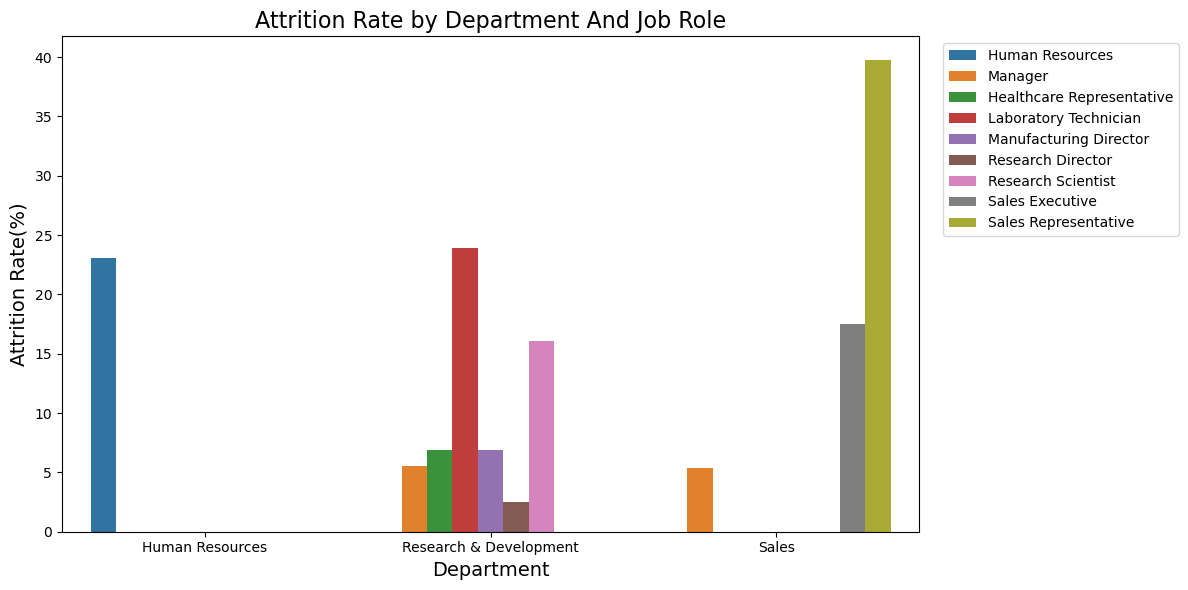

In [387]:
plt.figure(figsize = (12,6))

department_job = (df_clean.groupby(["Department", "JobRole"])["Attrition"].mean().mul(100).reset_index())

sns.barplot(data = department_job, x = "Department",
            y = "Attrition", hue = "JobRole")

plt.title("Attrition Rate by Department And Job Role", fontsize = 16)

plt.xlabel("Department", fontsize = 14)
plt.ylabel("Attrition Rate(%)",fontsize = 14)
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.savefig("charts/chart1_department_jobrole.png")
plt.show()

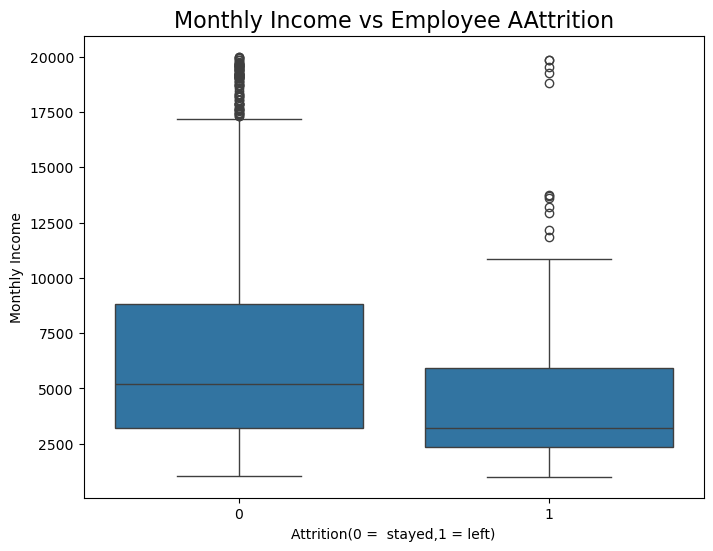

In [388]:
plt.figure(figsize = (8,6))

sns.boxplot(data = df_clean,
            x = "Attrition",
            y = "MonthlyIncome"
           )
plt.title("Monthly Income vs Employee AAttrition",fontsize = 16)
plt.xlabel("Attrition(0 =  stayed,1 = left)")
plt.ylabel("Monthly Income")
plt.savefig("charts/chart2_monthly_icome_boxplot.png")
plt.show()


           

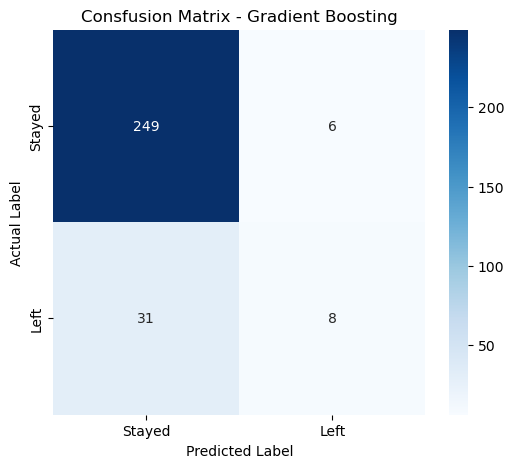

In [389]:
plt.figure(figsize =(6,5))

sns.heatmap(gradient_boosting_cm,
            annot = True,
            fmt ="d",
            cmap = "Blues",
            xticklabels = ["Stayed", "Left"],
            yticklabels = ["Stayed", "Left"]
)

plt.title("Consfusion Matrix - Gradient Boosting")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.savefig("Charts/chart3_consfusion_matrix.png")
plt.show()

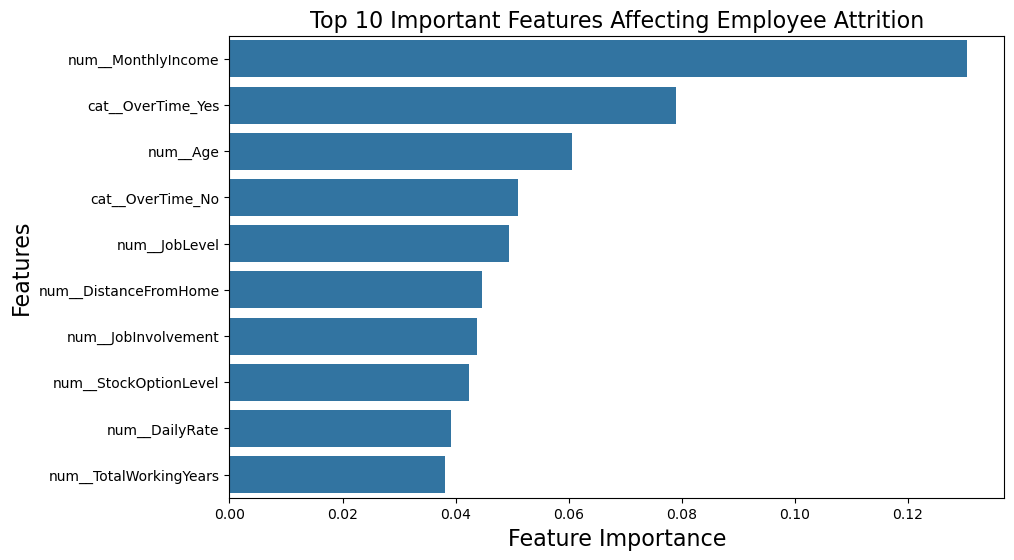

In [390]:
plt.figure(figsize = (10,6))

sns.barplot(data = imp_df.head(10),
            x = "Importance",
            y = "Feature",
           )
plt.title("Top 10 Important Features Affecting Employee Attrition", fontsize = 16)

plt.xlabel("Feature Importance", fontsize = 16)

plt.ylabel("Features", fontsize = 16)

plt.savefig("charts/chart4_feature_importance.png")

plt.show()

In [391]:
from sklearn.metrics import roc_curve
logistic_fpr, logistic_tpr, _ = roc_curve(
                                     y_test,logistic_prob
)

random_forest_fpr, random_forest_tpr, _ = roc_curve(
                                                y_test,random_forest_prob
)

gradient_boosting_fpr, gradient_boosting_tpr, _ = roc_curve(
                                                    y_test,gradient_boosting_prob
)

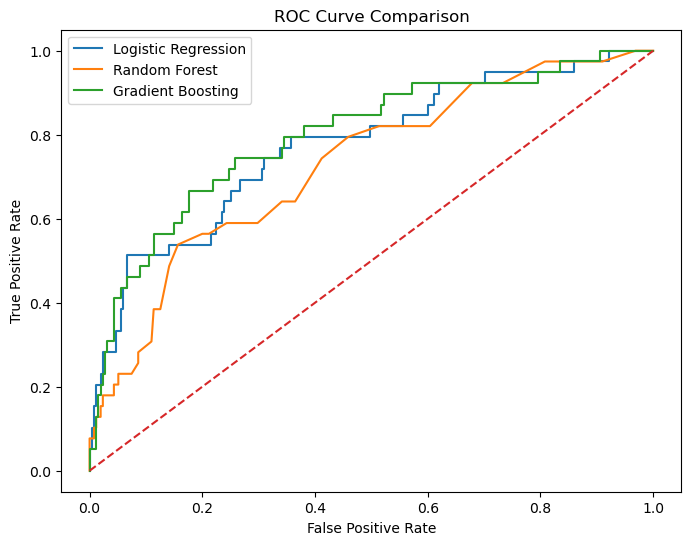

In [392]:
plt.figure(figsize=(8,6))

plt.plot(logistic_fpr,
         logistic_tpr,
         label="Logistic Regression"
)

plt.plot(random_forest_fpr,
         random_forest_tpr,
         label="Random Forest"
)

plt.plot(gradient_boosting_fpr,
         gradient_boosting_tpr,
         label="Gradient Boosting"
)

plt.plot([0,1],
         [0,1],
         linestyle="--"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("charts/chart5_roc_curve.png")
plt.show()

In [393]:
#TASK 7  HR Insights & Business Recommendations

In [394]:
# 1. Which three factors most strongly predict employee attrition?

# Based on the analysis, the three strongest factors influencing employee attrition are:

# Monthly Income
# Overtime
# Employee Age

# Employees with lower monthly income, frequent overtime and certain age groups showed a higher likelihood of leaving the company.

In [395]:
# 2. Which department or job role should HR prioritize for retention efforts?

# The Sales department recorded the highest employee attrition among all departments. Within job roles, Sales Representatives showed the highest exit rate. 
# HR should focus retention efforts on these employees by conducting regular career discussions, monitoring workload and improving employee engagement.

In [396]:
# 3. Does salary alone explain employee attrition?

# No, Although employees with lower monthly income were more likely to leave, salary was not the only reason. Overtime, employee age, job level, distance from home and work-related factors also influenced employee attrition.
# This indicates that employee retention requires a combination of financial and workplace improvements.

In [397]:
# 4. HR Recommendations

#1. Conduct regular one-to-one meetings with employees in the Sales department and employees who frequently work overtime to identify concerns before they decide to leave.

#2. Review salary growth, career development opportunities and employee benefits for lower-income employees to improve long-term employee retention.

In [398]:
# 5. Limitation of the Analysis

# This analysis is based only on the information available in the employee dataset. 

# Factors such as personal reasons, workplace relationships, management style, company culture and future business changes are not included. Therefore, the results should be used to support HR decisions rather than replace human judgement.